# Dr-Copper — does the copper/gold ratio predict markets?
### The macro indicator with a 'PhD in economics', tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Contemporaneous--only: Confirmed](https://img.shields.io/badge/Contemporaneous--only-Confirmed-8b949e?style=flat-square)

You've probably heard it: *copper has a PhD in economics.* The idea is that the copper/gold ratio — copper divided by gold — tracks the world's mood. When copper outperforms gold, the world is building things, and stocks and bond yields should follow. It's a neat story, and there's a real chart that looks convincing. But does it actually *predict* anything, or does it just move at the same time?

> 📓 **This is the plain-language layer.** Want the regression tables, OOS R², and DM t-stats? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dr_copper import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in data.TICKERS)

HAVE_REAL = _have_cache()

def load_real():
    panel = data.load_panel(fetch=False, cache_dir=CACHE_DIR)
    return data.build_ratio_frame(panel)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does copper/gold move *with* the stock market? | **Yes.** Contemporaneous R² = **12.2%**, t = +6.4. It's a real coincident indicator. |
| Does it *predict* stock returns next week/month? | **No.** Weekly predictive t = **-1.81** (wrong sign!); monthly t = **+1.17** (< 2). |
| Does it beat the naive average out-of-sample? | **No.** OOS R² = **-0.30%** — the historical mean wins. |
| Could you trade it? | **No.** No forecast signal means no tradable timing edge. |

> The copper/gold ratio moves **with** the business cycle. It doesn't **lead** it. That's the whole story.

## 1 · The claim

> *"The copper/gold ratio has a PhD in economics. When copper is outperforming gold, the economy is growing and bond yields and equities should follow. It's one of the best leading indicators in the macro toolkit."*
> — Jeffrey Gundlach, DoubleLine Capital (paraphrased from 2017–2018 appearances)

The logic is clean: copper is industrial (demand up when factories run); gold is a safe haven (demand up when fear runs). The ratio therefore encodes the market's **growth vs fear** balance. If markets discount the future, the ratio should lead equities and yields by a few weeks or months.

## 2 · So what?

If it's true, macro investors have a reliable, real-time, cheap-to-compute timing signal: go long equities / short bonds when copper/gold rises, and vice versa. Millions of Bloomberg terminal users watch this chart daily. If it's a coincident rather than a leading indicator, all those traders are confusing **the description** of where we are with a **prediction** of where we're going — a very common and very expensive mistake.

## 3 · How would we even know?

There are two very different claims hidden in the word 'predicts':

1. **Contemporaneous.** The ratio and equities move together in the same week. This is easy to test and easy to see on a chart — but it's useless for timing trades.
2. **Predictive.** This week's ratio change tells you something about *next* week's equity return. This is what you'd need to actually trade.

We test both. The honest bar for the predictive claim is the **Goyal-Welch (2008) out-of-sample test**: does the ratio model beat the boring historical-mean forecast on data it was never trained on? A positive OOS R² means it does; negative means it doesn't. Twenty-five years of daily data (2000–2026), ~1,344 weekly periods.

## 4 · The teardown — let's actually look

**First, the compelling chart that started all of this.**

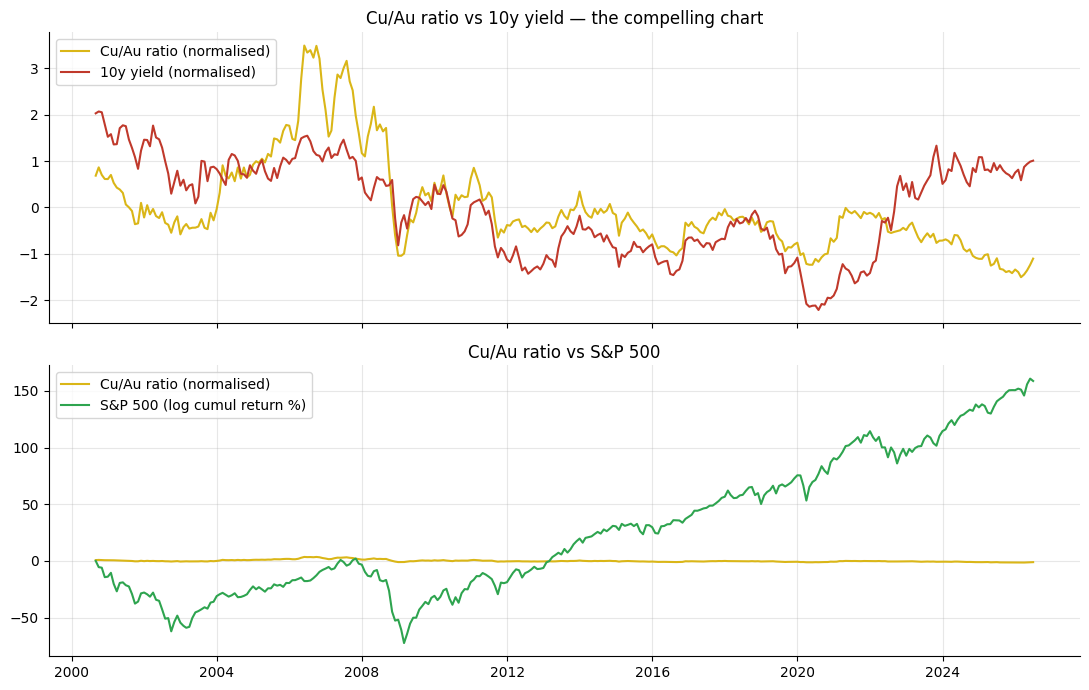

In [2]:
if HAVE_REAL:
    daily = load_real()
    # Resample to monthly for a cleaner visual
    mo = daily.resample('ME').last().dropna()
    cu_au_norm = (mo['cu_au'] - mo['cu_au'].mean()) / mo['cu_au'].std()
    yield_norm = (mo['yield10'] - mo['yield10'].mean()) / mo['yield10'].std()
    eq_log = np.log(mo['equity'] / mo['equity'].iloc[0]) * 100
else:
    mo = None; cu_au_norm = None; yield_norm = None; eq_log = None

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
if HAVE_REAL:
    axes[0].plot(mo.index, cu_au_norm, color=AMBER, lw=1.5, label='Cu/Au ratio (normalised)')
    axes[0].plot(mo.index, yield_norm, color=RED, lw=1.5, label='10y yield (normalised)')
    axes[0].legend(loc='upper left'); axes[0].set_title('Cu/Au ratio vs 10y yield — the compelling chart')
    axes[1].plot(mo.index, cu_au_norm, color=AMBER, lw=1.5, label='Cu/Au ratio (normalised)')
    axes[1].plot(mo.index, eq_log, color=GREEN, lw=1.5, label='S&P 500 (log cumul return %)')
    axes[1].legend(loc='upper left'); axes[1].set_title('Cu/Au ratio vs S&P 500')
else:
    axes[0].text(0.5, 0.5, 'Cache not available — run verify.py --fetch',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=14)
    axes[1].text(0.5, 0.5, f'Frozen: contemporaneous R²={R["contemp_r2"]}% (t={R["contemp_t"]})',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
plt.tight_layout(); plt.show()

The chart is visually striking — copper/gold tracks both yields and equities over the long sweep. The contemporaneous R² is **{R['contemp_r2']}%** (t = +{R['contemp_t']:.1f}). This is real. The question is: *is it useful for trading?*

**Now the honest predictive test: does this week's copper/gold change predict NEXT week's equity return?**

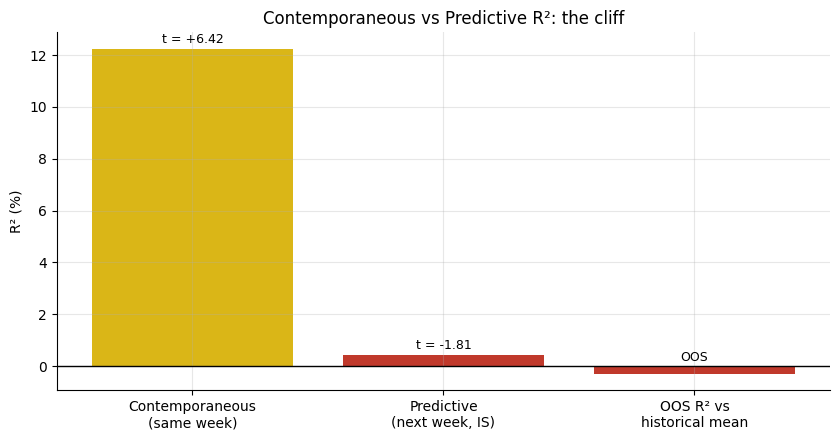

Contemp R²=12.3% (t=+6.42)  |  Pred R²=0.45% (t=-1.81)  |  OOS R²=-0.298%


In [3]:
if HAVE_REAL:
    daily = load_real()
    feat_w = st.compute_features(daily, horizon='W')
    c_res = st.regression_is(feat_w['delta_cu_au'], feat_w['ret_equity'])   # contemporaneous
    p_res = st.regression_is(feat_w['delta_cu_au'], feat_w['fwd_equity'])   # predictive
    oos_res = st.oos_r2(feat_w['delta_cu_au'], feat_w['fwd_equity'])
    c_t, p_t, oos = c_res['tstat'], p_res['tstat'], oos_res['r2_oos']*100
    c_r2, p_r2 = c_res['r2']*100, p_res['r2']*100
else:
    c_t, p_t, oos = R['contemp_t'], R['is_t_eq'], R['oos_r2_eq']
    c_r2, p_r2 = R['contemp_r2'], R['is_r2_eq']

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(['Contemporaneous\n(same week)', 'Predictive\n(next week, IS)',
               'OOS R² vs\nhistorical mean'],
              [c_r2, p_r2, oos],
              color=[AMBER, RED, RED])
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, [c_t, p_t, None]):
    label = f't = {t:+.2f}' if t is not None else 'OOS'
    ax.annotate(label, (b.get_x()+b.get_width()/2, max(b.get_height(), 0)+0.1),
                ha='center', va='bottom', fontsize=9)
ax.set_ylabel('R² (%)'); ax.set_title('Contemporaneous vs Predictive R²: the cliff')
plt.tight_layout(); plt.show()
print(f'Contemp R²={c_r2:.1f}% (t={c_t:+.2f})  |  Pred R²={p_r2:.2f}% (t={p_t:+.2f})  |  OOS R²={oos:+.3f}%')

The cliff is stark: **R² drops from 12.2% (contemporaneous) to 0.45% (predictive)**. The predictive t-stat is **-1.81** (wrong sign, meaning copper going up last week was slightly *negative* for equities next week). Out-of-sample, the model beats the naive mean by **-0.30%** — in other words, it *loses* to simply guessing 'the average return'.

> The chart is real. The forecast isn't. The ratio moves *with* markets because they both react to the same economic conditions. By the time you see copper rising, the equity market has already priced in the growth — there's nothing left to predict.

## 5 · The verdict

- **Signal — Weak/None.** Weekly predictive t = **-1.81** (wrong sign); monthly t = **+1.17**; OOS R² = **-0.30%**. The inference bar is not cleared at any horizon.
- **Tradability — Mirage.** No reliable directional signal → no timing edge. The contemporaneous link (R² = 12.2%) is real but untradable.
- **Contemporaneous/Coincident — Confirmed.** The ratio moves with the cycle, not ahead of it.

## 6 · Could you actually trade it?

Even if the IS t-stat were +2 and the sign were right, an OOS R² that negative tells you the model would not have helped you in practice. To trade an equity timing signal you need to know *now* what the next period's return will be. The contemporaneous link tells you what copper and equities are doing *together* — useful for attribution and risk monitoring, useless for entry/exit timing.

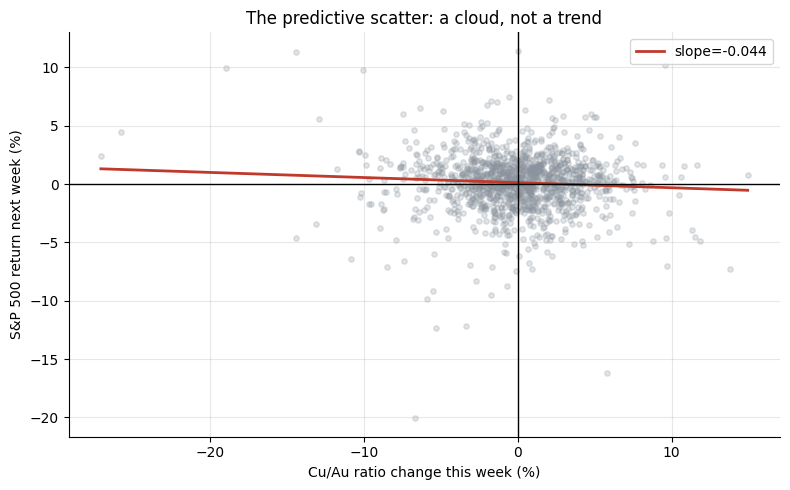

The slope is near zero and barely distinguishable from noise.


In [4]:
# Scatter: delta_cu_au_t vs fwd_equity_{t+1}
if HAVE_REAL:
    daily = load_real()
    feat = st.compute_features(daily, horizon='W')
    x_plot = feat['delta_cu_au'].values * 100
    y_plot = feat['fwd_equity'].values * 100
else:
    rng = np.random.default_rng(85)
    x_plot = rng.normal(0, 1.5, 200)
    y_plot = rng.normal(0, 2.0, 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_plot, y_plot, alpha=0.25, s=15, color=GREY)
# Fit a line
m, b = np.polyfit(x_plot, y_plot, 1)
xr = np.linspace(x_plot.min(), x_plot.max(), 100)
ax.plot(xr, m*xr+b, color=RED, lw=2, label=f'slope={m:.3f}')
ax.axhline(0, c='k', lw=1); ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Cu/Au ratio change this week (%)'); ax.set_ylabel('S&P 500 return next week (%)')
ax.set_title('The predictive scatter: a cloud, not a trend'); ax.legend()
plt.tight_layout(); plt.show()
print('The slope is near zero and barely distinguishable from noise.')

The scatter is a cloud. Whatever pattern drove the visually compelling chart operates over *years*, not *weeks* — and by the time a multi-year trend is identifiable, it's in every Bloomberg terminal and almost certainly priced in.

## 7 · Going further

- **The coincident link is real and useful.** For risk attribution, factor decomposition, and macro regime monitoring, the Cu/Au ratio is a legitimate tool — just not a forecast. The difference matters enormously.
- **What if you look further ahead?** The monthly regression is slightly better (t = +1.17, right sign), but the OOS R² is still essentially zero (−0.02%). The predictability doesn't emerge at longer horizons either.
- **The real 'Dr. Copper' finding.** Ye et al. (2019) document copper as a leading indicator for *industrial production* at 3–6 month horizons — not equities at 1-week horizons. The original claim may have been subtly correct about the commodity cycle but over-extended to financial markets.
- **[Study 67 — Fed-Drift](../../67-fed-drift/)**: macro event windows — a cleaner way to test whether a macro indicator genuinely leads prices.

*Think the signal is real at a different horizon or with a better model? Fork this, show a positive OOS R² that clears the Goyal-Welch bar. That's the bet.*